### Connexion à la DB DuckDB

In [ ]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


### Connexion à la DB / Import des Data


In [77]:
# Store database at project root
DB_NAME = Path("../amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [78]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 10 tables in the database:

1. all_events
2. historical_events
3. item_item_sim
4. loaded_files
5. new_events
6. product_popularity
7. segment_popularity
8. user_events
9. user_item_interactions
10. user_segments_kmeans


In [79]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌────────────────────────┐
│          name          │
│        varchar         │
├────────────────────────┤
│ all_events             │
│ historical_events      │
│ item_item_sim          │
│ loaded_files           │
│ new_events             │
│ product_popularity     │
│ segment_popularity     │
│ user_events            │
│ user_item_interactions │
│ user_segments_kmeans   │
├────────────────────────┤
│        10 rows         │
└────────────────────────┘



In [80]:
# Examine the all_events table
print("First 10 rows of all_events table:")
all_events_data = con.sql("""
    SELECT * FROM all_events LIMIT 10
""")
all_events_data.show()


# Examine the loaded_files table
print("\nContents of loaded_files table:")
loaded_files_data = con.sql("""
    SELECT * FROM loaded_files
""")
loaded_files_data.show()


First 10 rows of all_events table:
┌─────────────────────┬────────────┬────────────┬─────────────────────┬────────────────────────────────┬─────────┬─────────┬───────────┬──────────────────────────────────────┐
│     event_time      │ event_type │ product_id │     category_id     │         category_code          │  brand  │  price  │  user_id  │             user_session             │
│      timestamp      │  varchar   │  varchar   │       varchar       │            varchar             │ varchar │ double  │  varchar  │               varchar                │
├─────────────────────┼────────────┼────────────┼─────────────────────┼────────────────────────────────┼─────────┼─────────┼───────────┼──────────────────────────────────────┤
│ 2019-12-01 00:00:00 │ view       │ 1005105    │ 2232732093077520756 │ construction.tools.light       │ apple   │ 1302.48 │ 556695836 │ ca5eefc5-11f9-450c-91ed-380285a0bc80 │
│ 2019-12-01 00:00:00 │ view       │ 22700068   │ 2232732091643068746 │ NULL         

In [81]:
# Examine the all_events table
print("First 10 rows of all_events table:")
all_events_data = con.sql("""
    SELECT * FROM all_events LIMIT 10
""")
all_events_data.show()

# Show count of records in all_events
record_count = con.sql("""
    SELECT COUNT(*) as total_events FROM all_events
""")
record_count.show()

# Examine the loaded_files table
print("\nContents of loaded_files table:")
loaded_files_data = con.sql("""
    SELECT * FROM loaded_files
""")
loaded_files_data.show()


First 10 rows of all_events table:
┌─────────────────────┬────────────┬────────────┬─────────────────────┬────────────────────────────────┬─────────┬─────────┬───────────┬──────────────────────────────────────┐
│     event_time      │ event_type │ product_id │     category_id     │         category_code          │  brand  │  price  │  user_id  │             user_session             │
│      timestamp      │  varchar   │  varchar   │       varchar       │            varchar             │ varchar │ double  │  varchar  │               varchar                │
├─────────────────────┼────────────┼────────────┼─────────────────────┼────────────────────────────────┼─────────┼─────────┼───────────┼──────────────────────────────────────┤
│ 2019-12-01 00:00:00 │ view       │ 1005105    │ 2232732093077520756 │ construction.tools.light       │ apple   │ 1302.48 │ 556695836 │ ca5eefc5-11f9-450c-91ed-380285a0bc80 │
│ 2019-12-01 00:00:00 │ view       │ 22700068   │ 2232732091643068746 │ NULL         

In [82]:
DB_NAME = "amazing.duckdb"
TABLE_EVENTS = "all_events"
TABLE_USER_EVENTS = "user_events"
SAMPLE_USER_PERCENT = 0.001
BATCH_SIZE = 1000 

### Import de la table DuckDB

In [103]:
# Chargement de users avec au moins 10 événements 
print("Chargement d'un échantillon d'utilisateurs actifs...")

# Afficher les tables disponibles dans la base de données
tables_df = con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema = 'main'").fetch_df()
print("Tables disponibles dans la base de données :")
print(tables_df)

user_ids_df = con.execute(f"""
    SELECT user_id
    FROM all_events
    WHERE user_id IS NOT NULL
    GROUP BY user_id
""").fetch_df()

Chargement d'un échantillon d'utilisateurs actifs...
Tables disponibles dans la base de données :
               table_name
0              all_events
1       historical_events
2           item_item_sim
3            loaded_files
4              new_events
5      product_popularity
6      segment_popularity
7             user_events
8  user_item_interactions
9    user_segments_kmeans


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Normalisation et Standardisation des données

In [ ]:
user_df = con.execute("""
    SELECT 
        user_id,
        COUNT(*) AS nb_events
    FROM all_events
    WHERE user_id IS NOT NULL
    GROUP BY user_id
""").fetch_df()

user_counts = user_df["nb_events"]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
user_stats_df = con.execute("""
WITH user_agg AS (
    SELECT
        user_id,
        COUNT(*) AS nb_events,
        SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS total_views,
        SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS total_purchases,
        SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS total_spent,
        COALESCE(AVG(CASE WHEN event_type = 'purchase' THEN price END), 0) AS avg_basket
    FROM all_events
    GROUP BY user_id
)
SELECT *,
    CASE 
        WHEN total_views > 0 THEN total_purchases * 1.0 / total_views
        ELSE 0
    END AS conversion_rate
FROM user_agg
""").fetch_df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [155]:
user_counts = user_df["nb_events"].values

thresholds = np.arange(1, int(np.percentile(user_counts, 95)))
total_users = len(user_counts)

remaining = []

for t in thresholds:
    remaining.append(np.sum(user_counts >= t) / total_users)

remaining = np.array(remaining)

# Variation entre deux seuils
delta = np.abs(np.diff(remaining))

# Trouver ou la chute devient faible
knee_idx = np.argmax(delta < np.percentile(delta, 25))

optimal_threshold = thresholds[knee_idx]

print(f"knee approx : {optimal_threshold}")


knee approx : 87


In [154]:
thresholds = np.arange(1, 50)
remaining = []
for t in thresholds:
    remaining.append(np.sum(user_counts >= t) / len(user_counts))
remaining = np.array(remaining)

# Normalisation
x = (thresholds - thresholds.min()) / (thresholds.max() - thresholds.min())
y = (remaining - remaining.min()) / (remaining.max() - remaining.min())

dy = np.gradient(y)
ddy = np.gradient(dy)

optimal_idx = np.argmax(np.abs(ddy))
optimal_chute = thresholds[optimal_idx]

print(f"chute de la courbure : {optimal_chute}")


chute de la courbure : 2


In [156]:
user_counts = user_stats_df["nb_events"]

stats = user_counts.describe(percentiles=[0.25, 0.5, 0.75]).round(2)
mediane = stats["50%"]

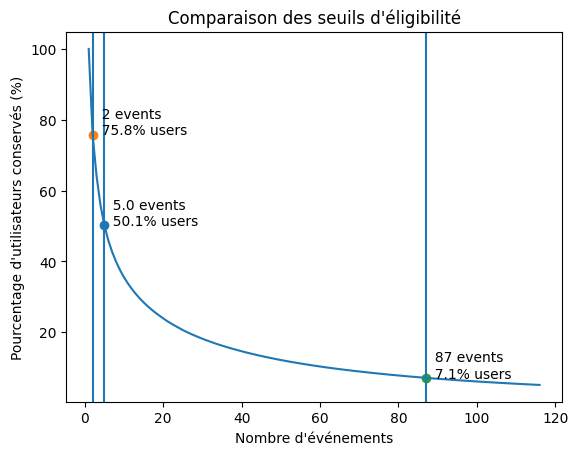

In [158]:
import numpy as np
import matplotlib.pyplot as plt

user_counts = user_df["nb_events"].values
total_users = len(user_counts)

max_threshold = int(np.percentile(user_counts, 95))
thresholds = np.arange(1, max_threshold)

remaining_percentages = []

for t in thresholds:
    remaining = np.sum(user_counts >= t)
    remaining_percentages.append((remaining / total_users) * 100)

remaining_percentages = np.array(remaining_percentages)

thresholds_to_show = [mediane, optimal_chute, optimal_threshold]

plt.figure()
plt.plot(thresholds, remaining_percentages)

for t in thresholds_to_show:
    if t < max_threshold:
        pct = (np.sum(user_counts >= t) / total_users) * 100
        plt.axvline(x=t)
        plt.scatter(t, pct)
        plt.text(t, pct, f"  {t} events\n  {pct:.1f}% users")

plt.xlabel("Nombre d'événements")
plt.ylabel("Pourcentage d'utilisateurs conservés (%)")
plt.title("Comparaison des seuils d'éligibilité")
plt.show()


Seuil optimal (méthode géométrique) : 1


C:\Users\Sebas\AppData\Local\Temp\ipykernel_16740\2328959646.py:3: RuntimeWarning: invalid value encountered in scalar divide
  y = (remaining - remaining.min()) / (remaining.max() - remaining.min())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

count    15639803.00
mean           26.32
std           111.73
min             1.00
25%             2.00
50%             5.00
75%            18.00
max        199179.00
Name: nb_events, dtype: float64


In [130]:

MIN_EVENTS_THRESHOLD = 5

sampled_user_ids = user_ids_df.sample(
    frac=SAMPLE_USER_PERCENT,
    random_state=42
)['user_id'].tolist()

print(f"Nombre d'utilisateurs échantillonnés : {len(sampled_user_ids)}")

print("Création des features utilisateurs par batch...")

user_features_list = []

for i in tqdm(range(0, len(sampled_user_ids), BATCH_SIZE),
              desc="Avancement user features",
              ncols=100):

    batch_ids = sampled_user_ids[i:i+BATCH_SIZE]
    batch_ids_str = ",".join(f"'{uid}'" for uid in batch_ids)

    batch_query = f"""
    WITH
        base_events AS (
            SELECT
                user_id,
                DATE_TRUNC('month', event_time) AS event_month_date,
                STRFTIME(event_time, '%Y-%m') AS event_month,
                STRFTIME(event_time, '%B') AS month_name,
                event_type,
                event_time,
                price,
                category_code,
                LEAD(event_time) OVER (
                    PARTITION BY user_id, DATE_TRUNC('month', event_time) 
                    ORDER BY event_time
                ) AS next_event_time
            FROM {TABLE_EVENTS}
            WHERE user_id IN ({batch_ids_str})
        ),
        features AS (
            SELECT
                user_id,
                MAX(event_month_date) AS event_month_date,
                MAX(event_month) AS event_month,
                MAX(month_name) AS month_name,
                COUNT(*) AS total_events,
                SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS total_views,
                SUM(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS total_carts,
                SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS total_purchases,
                AVG(EXTRACT(EPOCH FROM (next_event_time - event_time))) AS avg_time_between_events,
                SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS total_spent,
                COALESCE(AVG(CASE WHEN event_type = 'purchase' THEN price END), 0) AS avg_basket,
                MAX(event_time) AS last_event_time
            FROM base_events
            GROUP BY user_id, event_month
        )
    SELECT
        *,
        CASE 
            WHEN (total_views + total_carts) > 0
            THEN LEAST(
                    total_purchases * 1.0 / (total_views + total_carts),
                    1
                )
            ELSE 0
        END AS conversion_rate,

        CASE 
            WHEN total_events > 0 
            THEN total_purchases * 1.0 / total_events 
            ELSE 0 
        END AS purchase_ratio,

        DATE_PART(
            'day',
            (event_month_date + INTERVAL '1 month') - last_event_time
        ) AS days_since_last_event,
        
        CASE
            WHEN total_events >= {MIN_EVENTS_THRESHOLD}
            THEN TRUE
            ELSE FALSE
        END AS is_flagged_user

    FROM features
    """

    batch_features = con.execute(batch_query).fetch_df()

    user_features_list.append(batch_features)

# Fusion de tous les batchs
user_features = pd.concat(user_features_list, ignore_index=True)

# Vérification des NaN
print("Vérification des NaN")
nan_summary = user_features.isna().sum()
print("Résumé des NaN par colonne :")
print(nan_summary[nan_summary > 0])

users_with_nan = user_features[user_features.isna().any(axis=1)]
print(f"Nombre d'utilisateurs avec des NaN : {len(users_with_nan)}")
print("Exemples d'utilisateurs avec NaN :")
print(users_with_nan.head(10))


Nombre d'utilisateurs échantillonnés : 15640
Création des features utilisateurs par batch...


Avancement user features:   0%|                                              | 0/16 [00:00<?, ?it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Avancement user features:   6%|██▍                                   | 1/16 [00:02<00:32,  2.19s/it]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Avancement user features:  88%|████████████████████████████████▍    | 14/16 [00:30<00:04,  2.16s/it]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Avancement user features: 100%|█████████████████████████████████████| 16/16 [00:34<00:00,  2.14s/it]

Vérification des NaN
Résumé des NaN par colonne :
avg_time_between_events    7282
dtype: int64
Nombre d'utilisateurs avec des NaN : 7282
Exemples d'utilisateurs avec NaN :
      user_id event_month_date event_month month_name  total_events  \
15  587372441       2019-12-01     2019-12   December             1   
19  548118397       2019-11-01     2019-11   November             1   
38  563341301       2019-11-01     2019-11   November             1   
40  561151214       2019-10-01     2019-10    October             1   
51  588687396       2019-12-01     2019-12   December             1   
70  545262249       2020-03-01     2020-03      March             1   
74  552295066       2019-10-01     2019-10    October             1   
75  634345374       2020-04-01     2020-04      April             1   
77  514975596       2020-01-01     2020-01    January             1   
90  641128572       2020-04-01     2020-04      April             1   

    total_views  total_carts  total_purchases 

In [131]:
con.execute("""
    SELECT COUNT(*) AS nb_anomalies
    FROM user_events
    WHERE conversion_rate > 1 AND is_flagged_user  = TRUE
""").fetch_df()

,nb_anomalies
0,0


In [132]:
con.execute("""
    SELECT COUNT(*) AS total_rows
    FROM user_events
    WHERE is_flagged_user  = TRUE
""").fetch_df()


,total_rows
0,13438


In [133]:
con.execute("""
    SELECT *
    FROM user_events
    WHERE conversion_rate > 1 AND is_flagged_user  = TRUE
""").fetch_df()

,user_id,event_month_date,event_month,month_name,total_events,total_views,total_carts,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event,is_flagged_user


In [ ]:
# Standardisation
print("Standardisation des features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_features.drop(columns=["last_event_time"]))

Standardisation des features...


In [ ]:
false_users = user_features[~user_features["is_model_eligible"]]

print(f"check is_model_eligible : {len(false_users)}")
false_users.head(10)

NameError: name 'user_features' is not defined

In [ ]:
#  Sauvegarde des résultats dans DuckDB
print(f"Sauvegarde dans {TABLE_USER_EVENTS}...")
con.execute(f"DROP TABLE IF EXISTS {TABLE_USER_EVENTS}")
con.register("temp_user_features", user_features)
con.execute(f"CREATE TABLE {TABLE_USER_EVENTS} AS SELECT * FROM temp_user_features")

Sauvegarde dans user_events...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
def incremental_update(con, min_events=5):

    # Agrégation des nouveaux events
    con.execute("""
        CREATE OR REPLACE TEMP TABLE new_agg AS
        SELECT
            user_id,
            COUNT(*) AS new_events,
            SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END) AS new_views,
            SUM(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS new_purchases,
            SUM(CASE WHEN event_type='purchase' THEN price ELSE 0 END) AS new_spent,
            MAX(event_time) AS new_last_event_time
        FROM new_events
        GROUP BY user_id;
    """)

    # Update existants
    con.execute("""
        UPDATE user_features
        SET
            total_events = total_events + new_agg.new_events,
            total_views = total_views + new_agg.new_views,
            total_purchases = total_purchases + new_agg.new_purchases,
            total_spent = total_spent + new_agg.new_spent,
            last_event_time = GREATEST(last_event_time, new_agg.new_last_event_time)
        FROM new_agg
        WHERE user_features.user_id = new_agg.user_id;
    """)

    # Insert nouveaux utilisateurs
    con.execute("""
        INSERT INTO user_features
        SELECT
            user_id,
            new_events,
            new_views,
            new_purchases,
            NULL,
            new_spent,
            0,
            new_last_event_time,
            0,
            0,
            0,
            FALSE
        FROM new_agg
        WHERE user_id NOT IN (
            SELECT user_id FROM user_features
        );
    """)

    # Recalcul du flag
    con.execute(f"""
        UPDATE user_features
        SET is_model_eligible = (total_events >= {min_events});
    """)

    print("Maj terminée.")


In [ ]:
# Test de fonction d'incrémentation ne pas RUN

def create_user_features_table(con, table_events="all_events", min_events=5):
    """
    Crée la table user_features à partir d'une table d'événements.
    """

    query = f"""
    CREATE OR REPLACE TABLE user_features AS
    WITH base_events AS (
        SELECT
            user_id,
            event_type,
            event_time,
            price,
            LEAD(event_time) OVER (
                PARTITION BY user_id
                ORDER BY event_time
            ) AS next_event_time
        FROM {table_events}
        WHERE user_id IS NOT NULL
    ),
    features AS (
        SELECT
            user_id,
            COUNT(*) AS total_events,
            SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS total_views,
            SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS total_purchases,
            AVG(EXTRACT(EPOCH FROM (next_event_time - event_time))) AS avg_time_between_events,
            SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS total_spent,
            COALESCE(AVG(CASE WHEN event_type = 'purchase' THEN price END), 0) AS avg_basket,
            MAX(event_time) AS last_event_time
        FROM base_events
        GROUP BY user_id
    )
    SELECT
        *,
        CASE 
            WHEN total_views > 0 
            THEN total_purchases * 1.0 / total_views 
            ELSE 0 
        END AS conversion_rate,
        CASE 
            WHEN total_events > 0 
            THEN total_purchases * 1.0 / total_events 
            ELSE 0 
        END AS purchase_ratio,
        DATE_PART(
            'day',
            CURRENT_TIMESTAMP - last_event_time
        ) AS days_since_last_event,
        CASE
            WHEN total_events >= {min_events}
            THEN TRUE
            ELSE FALSE
        END AS is_model_eligible
    FROM features;
    """

    con.execute(query)
    print("user_features créé")


split_date = "2020-02-15"

con.execute(f"""
CREATE OR REPLACE TABLE historical_events AS
SELECT *
FROM all_events
WHERE event_time <= TIMESTAMP '{split_date}';
""")

con.execute(f"""
CREATE OR REPLACE TABLE new_events AS
SELECT *
FROM all_events
WHERE event_time > TIMESTAMP '{split_date}';
""")

create_user_features_table(con, table_events="all_events", min_events=5)



In [ ]:
user_before = con.execute("""
    SELECT user_id, total_events, is_model_eligible
    FROM user_features
    WHERE is_model_eligible = FALSE
    LIMIT 1
""").fetch_df()

user_before

In [ ]:
incremental_update(con, min_events=5)

con.execute("""
SELECT 
    COUNT(*) 
FROM user_features
WHERE is_model_eligible = TRUE
""").fetchall()

In [ ]:
con.close()